# Assignment 1: Building Neural Networks for Image Classification

## Overview
Welcome back to Assignment 1! In this assignment, you'll dive into the fascinating realm of deep learning by building and training neural networks for image classification and object detection tasks using the PyTorch framework. You'll work with two popular datasets: MNIST for image classification and CIFAR-100 for object detection. Throughout the assignment, you'll also fine-tune your models to achieve optimal results.

## Part 3: Achieve Best Accuracy
In the final section of the assignment, you'll take your models to the next level by modifying the model and achieving benchmark performance. You'll experiment with different architectures, hyperparameters, learning rates, and optimization techniques to achieve the best possible accuracy for object classification (CIFAR-100). Your journey will involve analyzing the impact of these changes on the models' accuracy and convergence. Feel free to write your own modules, and make changes to starter code to achieve highest possible accuracy. Results are expected to be submitted in the same format as previous sections however.

Note: You can implement one of the AlexNet, ResNet18, ResNet50, or other architectures discussed in class. However, No transfer learning or pretrained models allowed.

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cuda':
    print(f" {torch.cuda.get_device_name(0)}")
# Specify font family to avoid font warnings on Colab
plt.rcParams['font.family'] = 'DejaVu Sans'

 NVIDIA A100 80GB PCIe


In [9]:
from data import get_dataloaders
import neural_network
import trainer
import visualize

In [10]:
# Hyperparameters
# TODO: Experiment with different hyperparameters
batch_size = 128
learning_rate = 0.1
epochs = 40

In [11]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    transforms.RandomErasing(p=0.5),
])
 # TODO: note that you want to keep
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
  # TODO

trainloader, testloader = get_dataloaders(
    dataset_name="cifar100", 
    batch_size=batch_size, 
    train_transforms=transform_train, 
    test_transforms=transform_test
)

Files already downloaded and verified
Files already downloaded and verified


In [12]:
# TODO: Initialize the model, loss function, and optimizer
model = neural_network.BetterModel(num_classes=100, in_channels=3)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

In [13]:
# TODO: Training loop
train_losses, test_losses = trainer.train(
    model, optimizer, criterion, trainloader, testloader, epochs, device, scheduler
)

Epoch 1/40 - Train Loss: 4.035684632523285
Epoch 1/40 - Test Loss: 3.694316842887975
Epoch 1/40 - Test Accuracy: 11.56%
Epoch 2/40 - Train Loss: 3.530677542966955
Epoch 2/40 - Test Loss: 3.280176069163069
Epoch 2/40 - Test Accuracy: 19.38%
Epoch 3/40 - Train Loss: 3.1520725339270004
Epoch 3/40 - Test Loss: 3.070564988293225
Epoch 3/40 - Test Accuracy: 24.01%
Epoch 4/40 - Train Loss: 2.7765592016527414
Epoch 4/40 - Test Loss: 2.6886548211302936
Epoch 4/40 - Test Accuracy: 31.35%
Epoch 5/40 - Train Loss: 2.456656473371989
Epoch 5/40 - Test Loss: 2.5541210174560547
Epoch 5/40 - Test Accuracy: 34.46%
Epoch 6/40 - Train Loss: 2.21802674687427
Epoch 6/40 - Test Loss: 2.168438455726527
Epoch 6/40 - Test Accuracy: 42.41%
Epoch 7/40 - Train Loss: 2.0448017181337947
Epoch 7/40 - Test Loss: 2.321620668037028
Epoch 7/40 - Test Accuracy: 40.39%
Epoch 8/40 - Train Loss: 1.9115954210691135
Epoch 8/40 - Test Loss: 2.188451318801204
Epoch 8/40 - Test Accuracy: 43.07%
Epoch 9/40 - Train Loss: 1.80328290

# Visualize Final Results: Best Model - CIFAR 100

In [14]:
# Evaluate the models
accuracy = trainer.evaluate_accuracy(model, testloader, device)
train_acc = trainer.evaluate_accuracy(model, trainloader, device)
# Print test accuracy
print("C6_randomerasing Model Test Accuracy:", accuracy)
print("C6_randomerasing Train Accuracy:", train_acc)

C6_randomerasing Model Test Accuracy: 75.99000000000001
C6_randomerasing Train Accuracy: 95.38600000000001


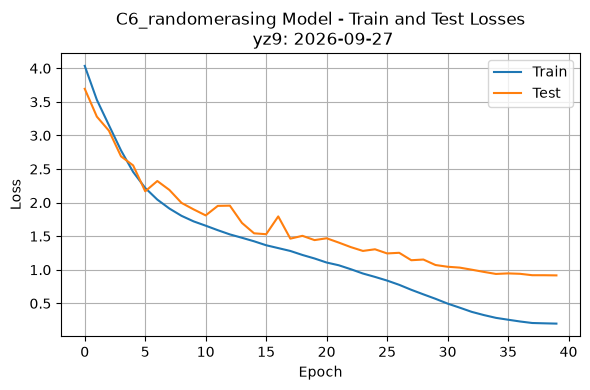

In [15]:
# Plot train and test losses
visualize.visualize_loss(train_losses, test_losses, "C6_randomerasing Model")

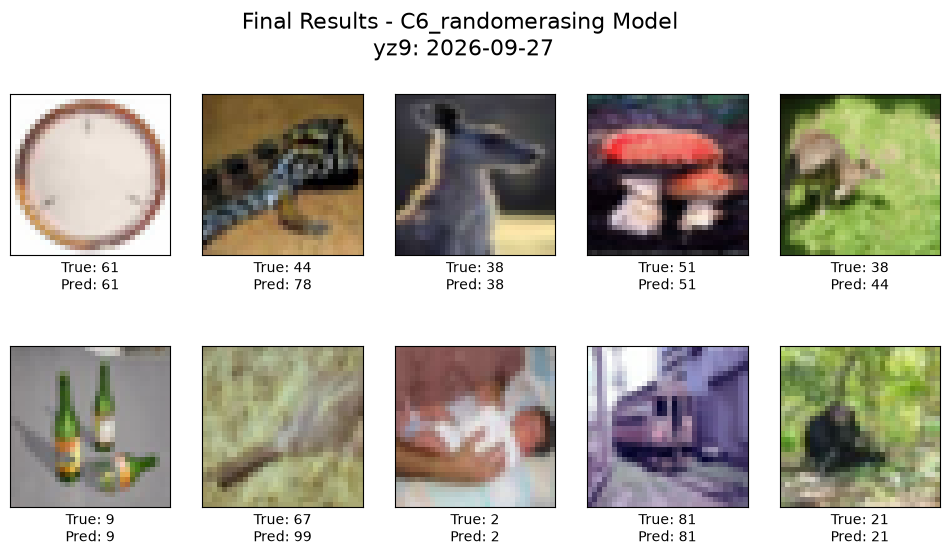

In [16]:
# Visualize the final results
visualize.visualize_images(model, testloader.dataset, device, "C6_randomerasing Model")